<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [2]:
!pip install pandas

In [1]:
!pip install matplotlib
!pip install seaborn 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 115.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  10.1MB/s    in 16s     

2026-09-04 09:35:21 (9.64 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



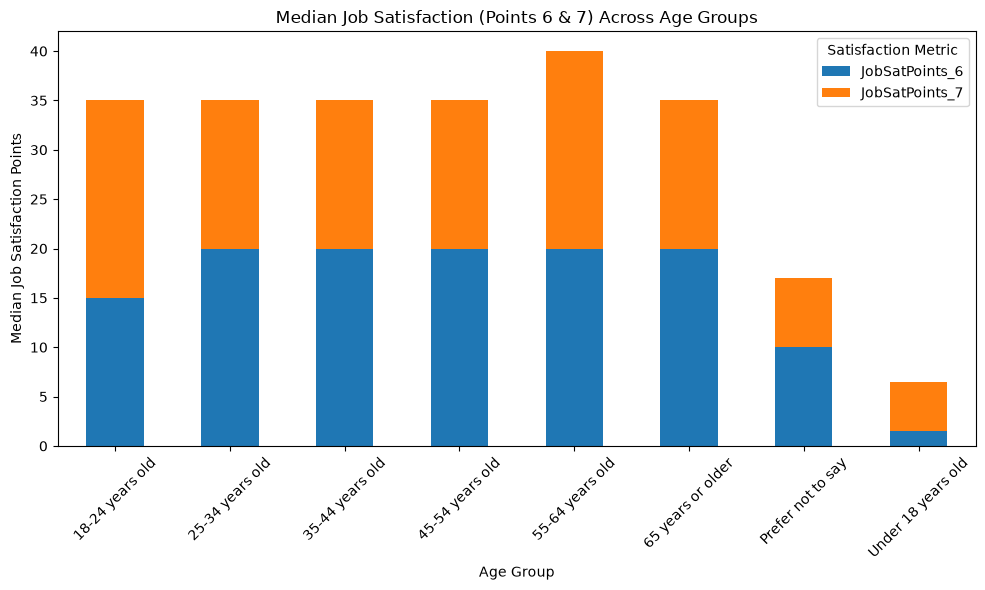

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by 'Age' and calculate the median for the required columns
age_jobsat = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# Create a stacked bar chart
age_jobsat.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Median Job Satisfaction (Points 6 & 7) Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Median Job Satisfaction Points')
plt.xticks(rotation=45)
plt.legend(title='Satisfaction Metric')
plt.tight_layout()

plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


/tmp/ipykernel_407/4176313309.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

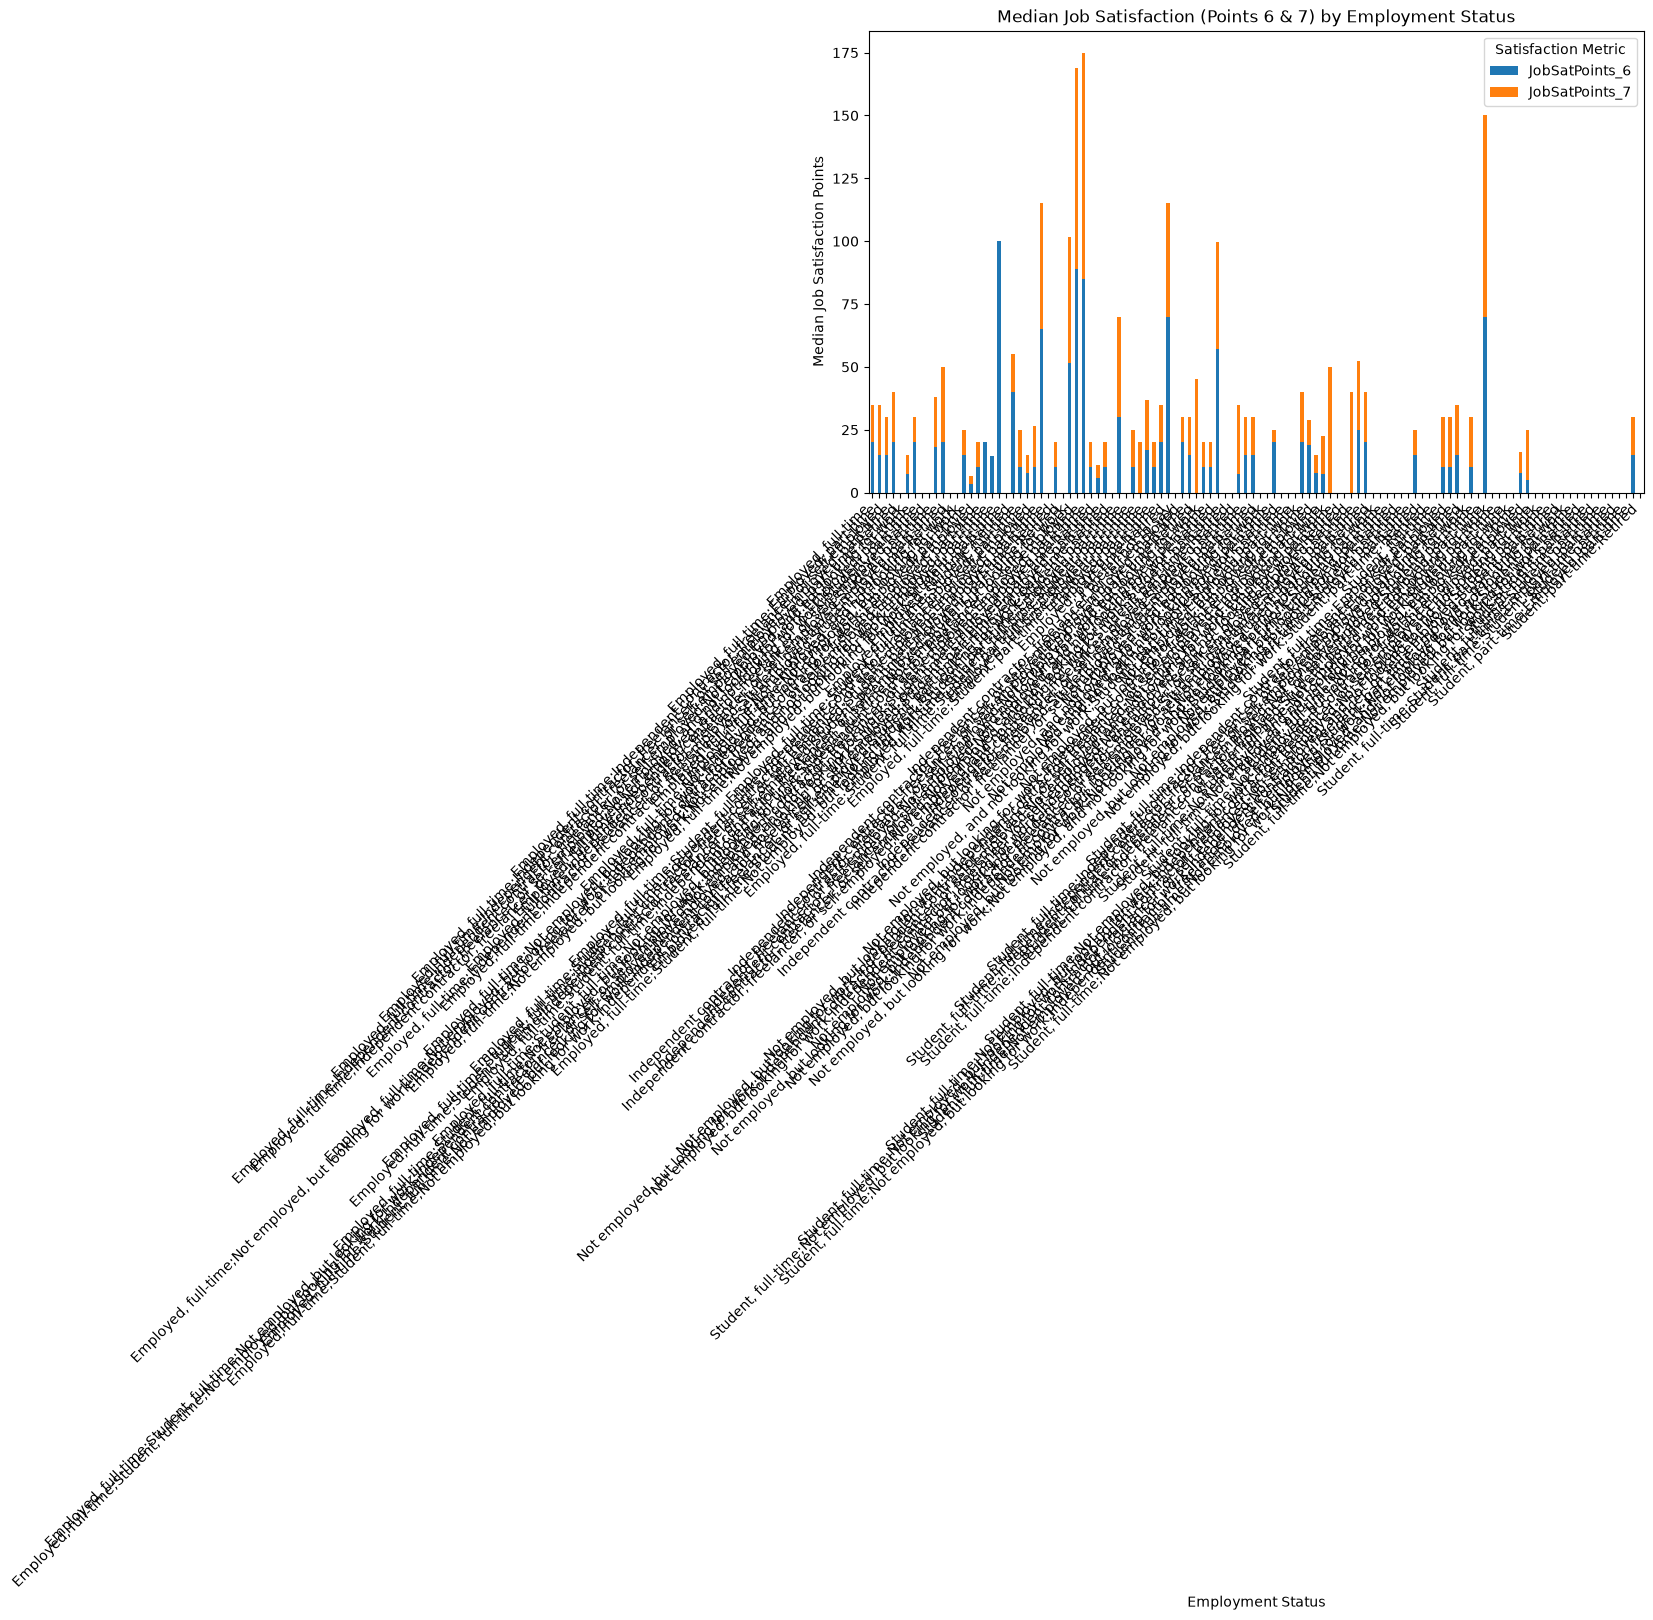

In [8]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# Group by 'Employment' and calculate the median for the required satisfaction columns
emp_jobsat = df.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# Create a stacked bar chart
emp_jobsat.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Median Job Satisfaction (Points 6 & 7) by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Median Job Satisfaction Points')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Satisfaction Metric')
plt.tight_layout()

plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


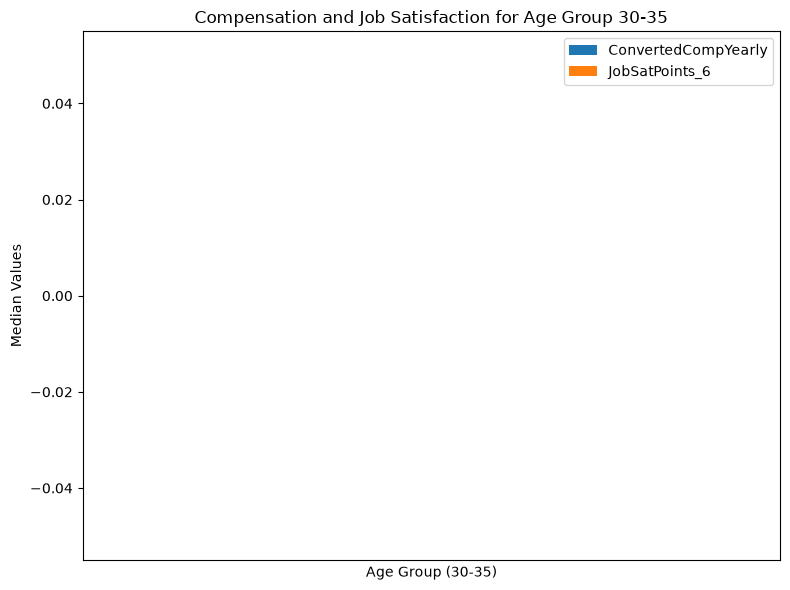

In [9]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# Filter dataset for respondents aged 30-35
df_30_35 = df[df['Age'] == '30-35']

# Calculate the median values for ConvertedCompYearly and JobSatPoints_6
median_vals = df_30_35[['ConvertedCompYearly', 'JobSatPoints_6']].median().to_frame().T

# Create a stacked bar chart
median_vals.plot(kind='bar', stacked=True, figsize=(8, 6))

plt.title('Compensation and Job Satisfaction for Age Group 30-35')
plt.xlabel('Age Group (30-35)')
plt.ylabel('Median Values')
plt.xticks([])  # Hide x-ticks since it's a single group summary
plt.legend(['ConvertedCompYearly', 'JobSatPoints_6'])
plt.tight_layout()

plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


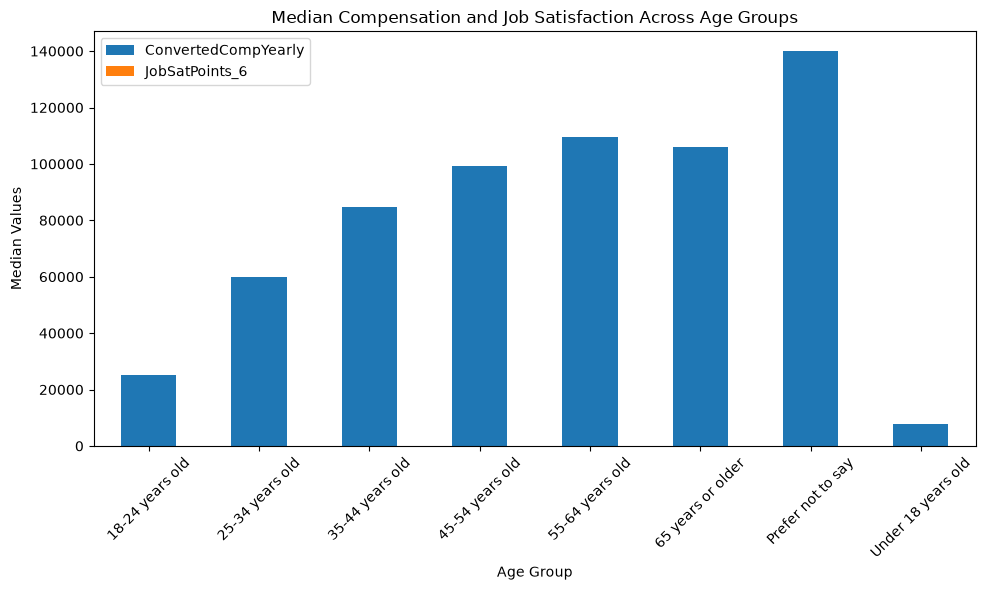

In [13]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# Group by 'Age' and calculate median for ConvertedCompYearly and JobSatPoints_6
age_comp_sat = df.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()

# Create stacked bar chart
age_comp_sat.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Median Compensation and Job Satisfaction Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Median Values')
plt.xticks(rotation=45)
plt.legend(['ConvertedCompYearly', 'JobSatPoints_6'])
plt.tight_layout()

plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


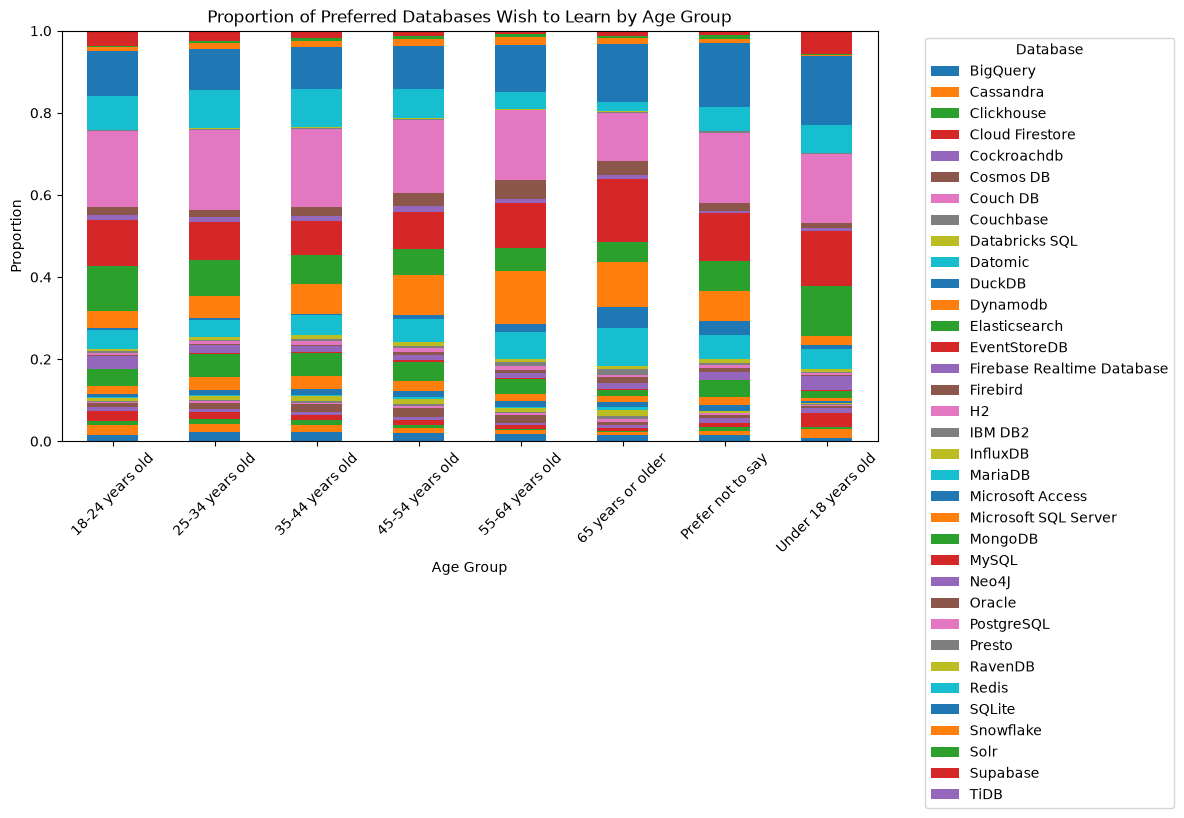

In [14]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# If 'DatabaseWantToWorkWith' contains semicolon-separated values, explode them
df_db = df.copy()
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.split(';')
df_db = df_db.explode('DatabaseWantToWorkWith')

# Calculate counts by Age group and Database
db_counts = df_db.groupby(['Age', 'DatabaseWantToWorkWith']).size().unstack(fill_value=0)

# Calculate proportions (normalize across each age group so rows sum to 1.0)
db_props = db_counts.div(db_counts.sum(axis=1), axis=0)

# Plot stacked bar chart showing proportions
db_props.plot(kind='bar', stacked=True, figsize=(12, 7))

plt.title('Proportion of Preferred Databases Wish to Learn by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Database', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


/tmp/ipykernel_407/3982189142.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

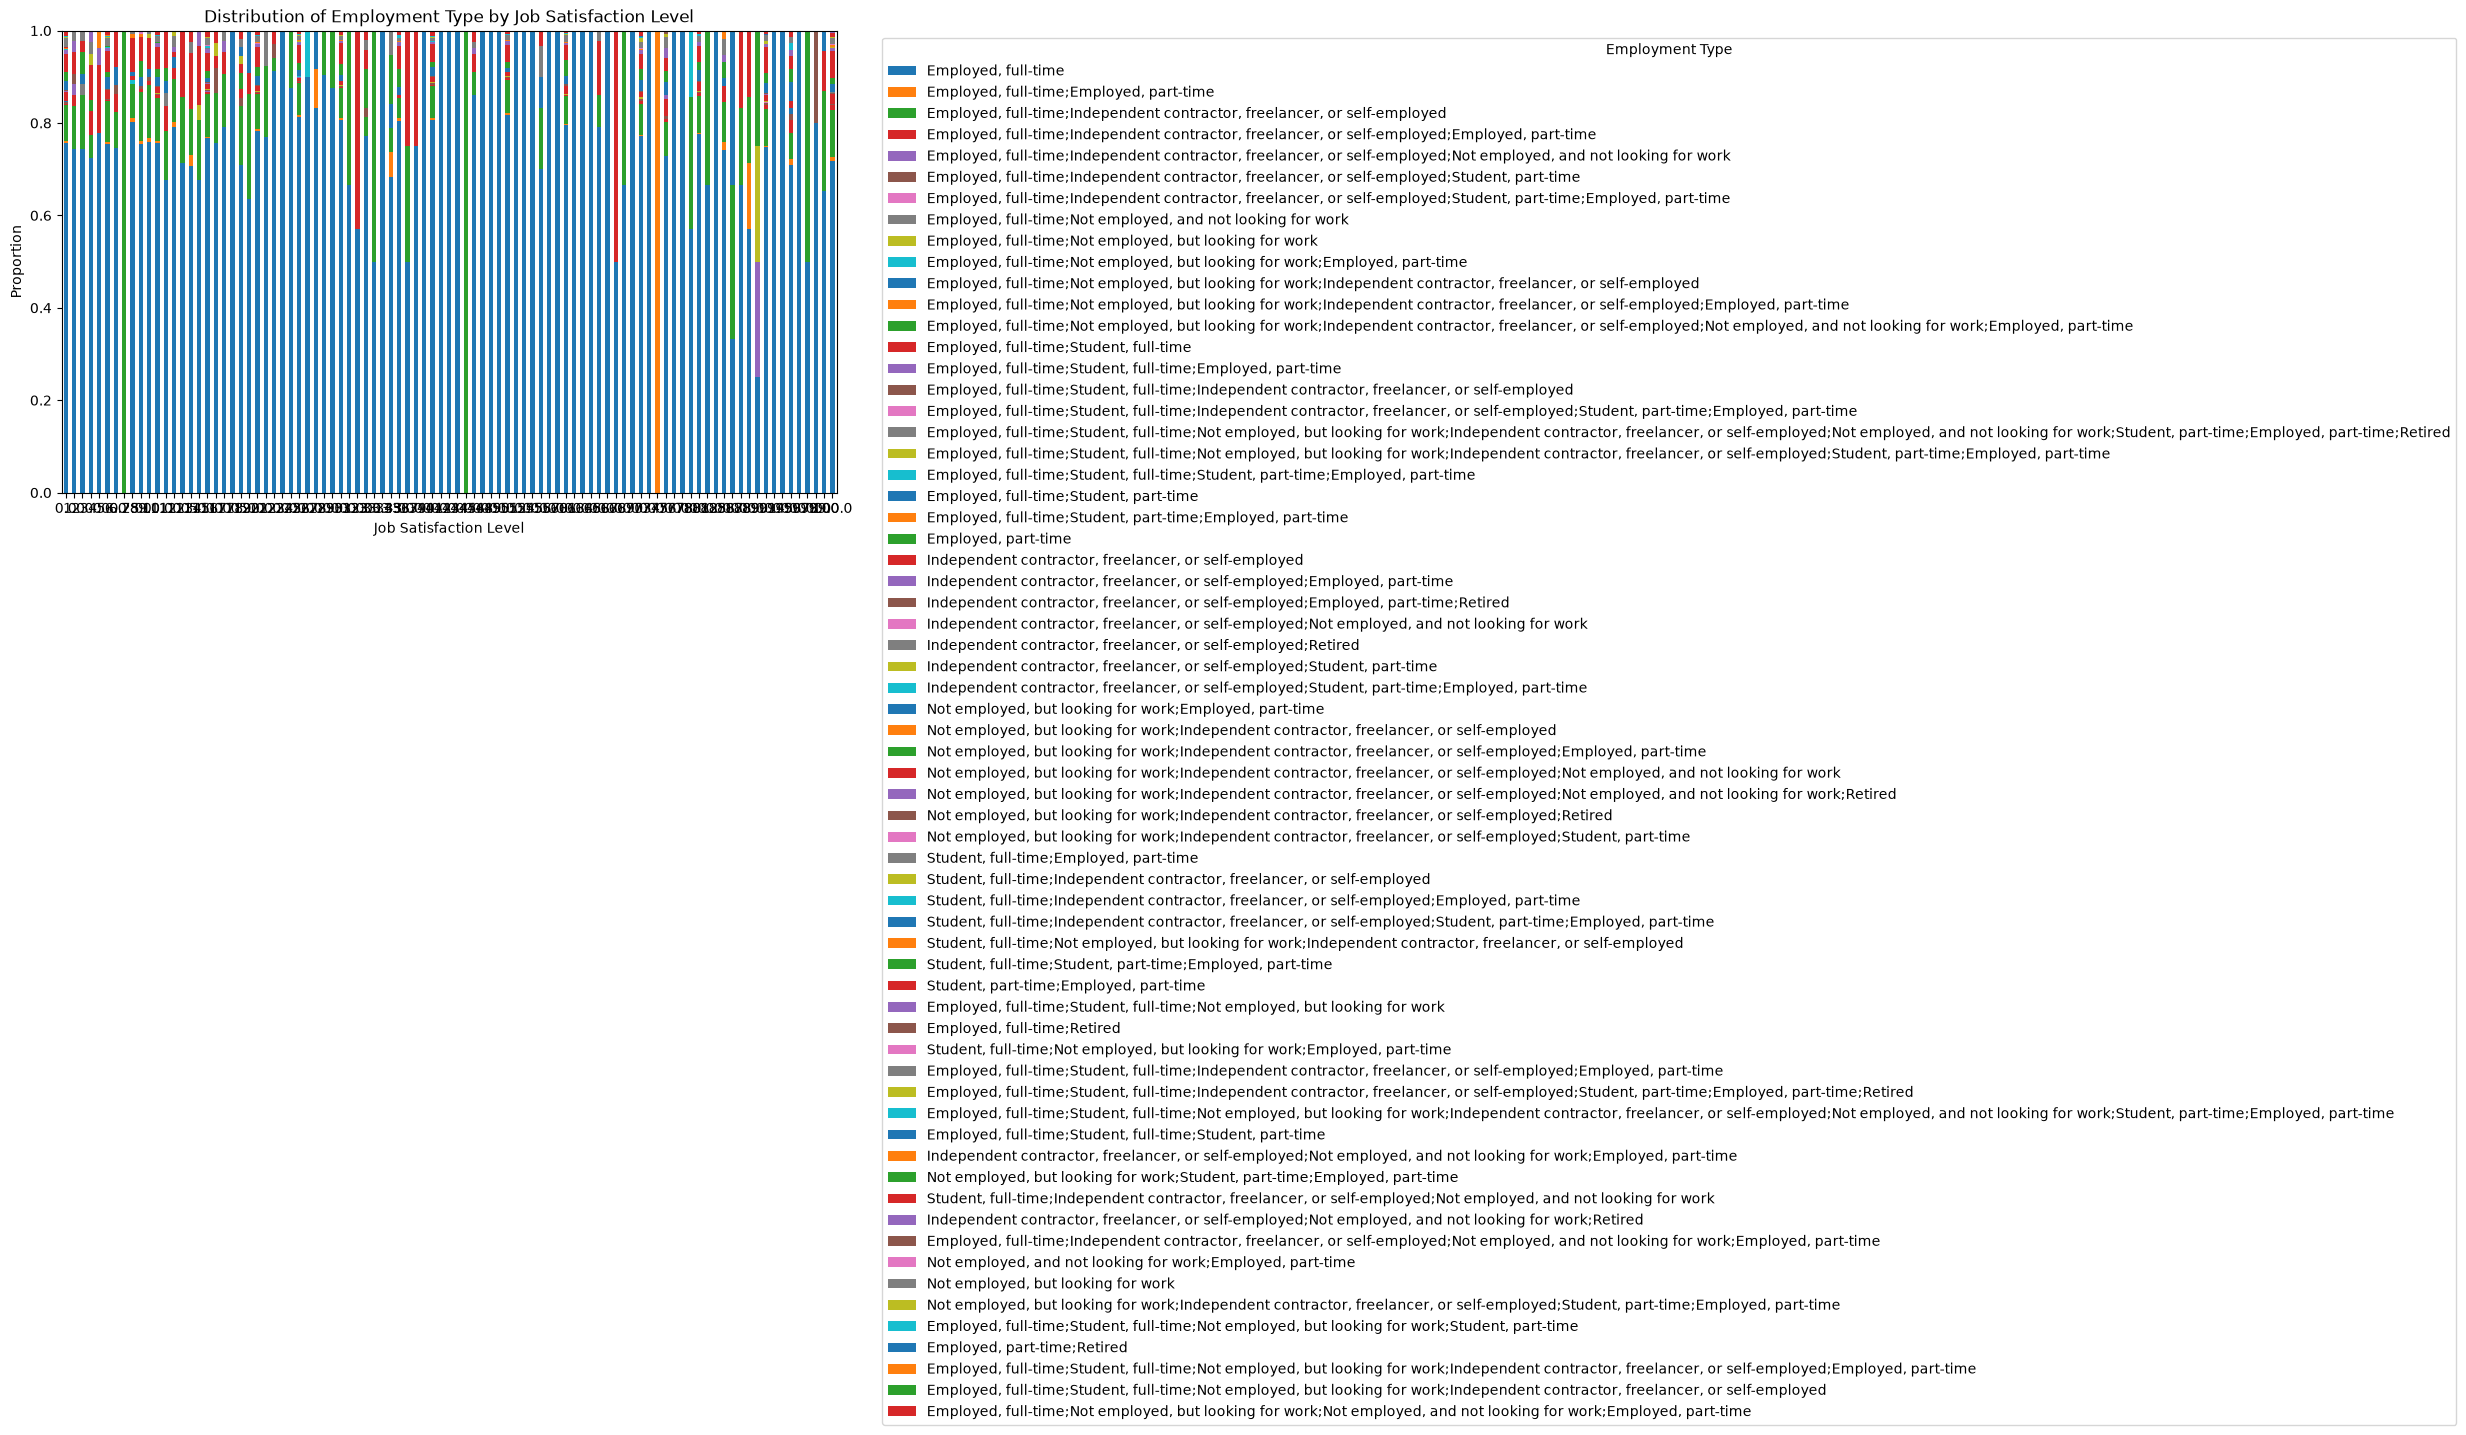

In [11]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# Group by JobSatPoints_6 (or preferred satisfaction column) and Employment status
emp_sat_counts = df.groupby(['JobSatPoints_6', 'Employment']).size().unstack(fill_value=0)

# Calculate proportions for each job satisfaction level
emp_sat_props = emp_sat_counts.div(emp_sat_counts.sum(axis=1), axis=0)

# Plot stacked bar chart
emp_sat_props.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Distribution of Employment Type by Job Satisfaction Level')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show() 

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


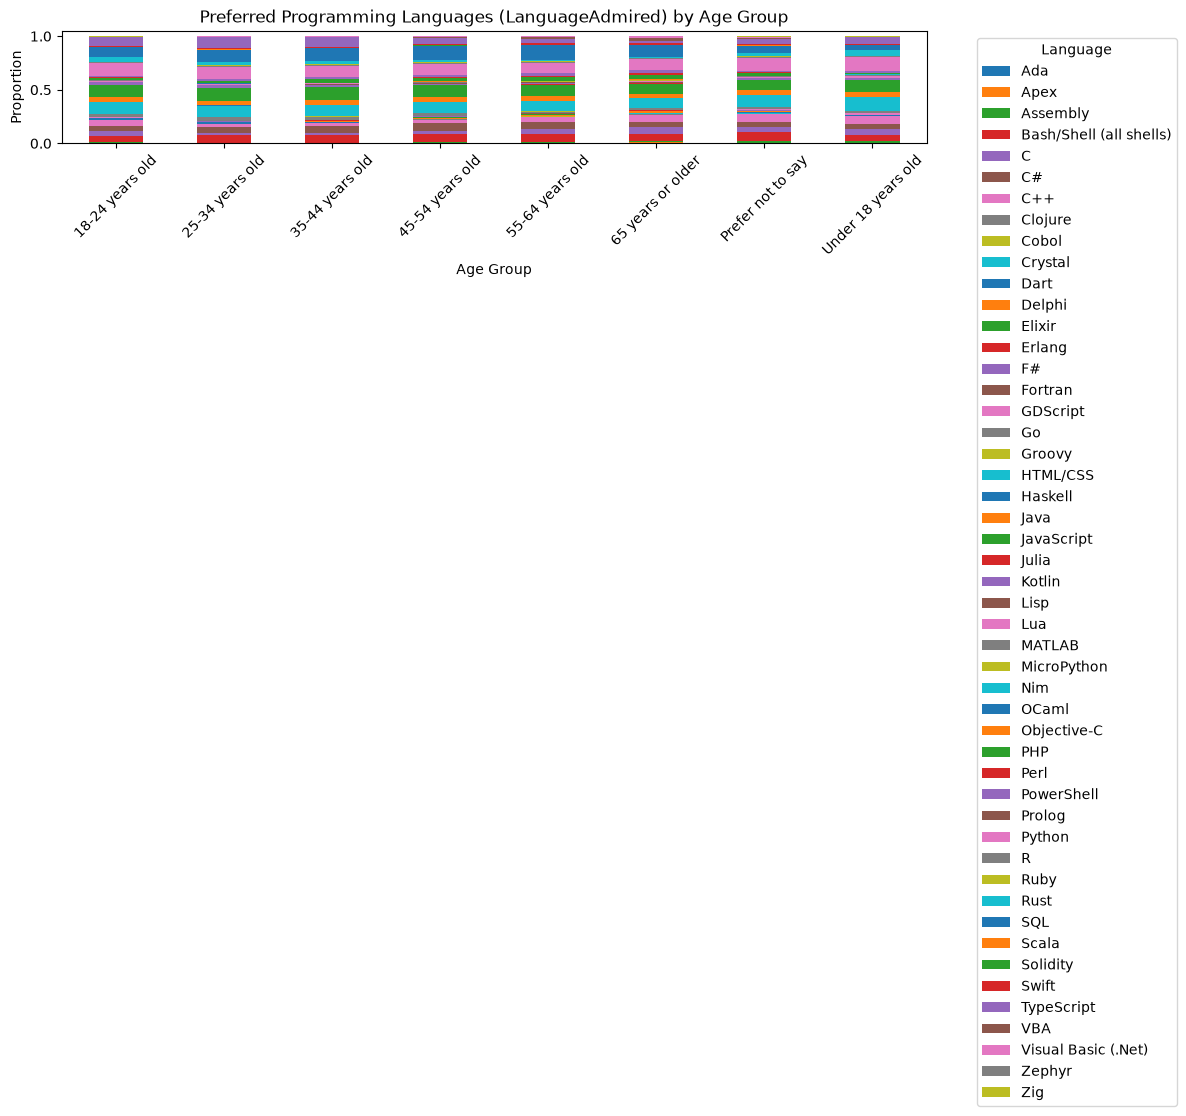

In [10]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# Handle delimited values in 'LanguageAdmired' column if multiple languages are listed
df_lang = df.copy()
df_lang['LanguageAdmired'] = df_lang['LanguageAdmired'].str.split(';')
df_lang = df_lang.explode('LanguageAdmired')

# Count occurrences across Age groups and LanguageAdmired
lang_counts = df_lang.groupby(['Age', 'LanguageAdmired']).size().unstack(fill_value=0)

# Normalize by row to get proportions per age group
lang_props = lang_counts.div(lang_counts.sum(axis=1), axis=0)

# Plot stacked bar chart
lang_props.plot(kind='bar', stacked=True, figsize=(12, 7))

plt.title('Preferred Programming Languages (LanguageAdmired) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show() 

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


/tmp/ipykernel_407/663233238.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

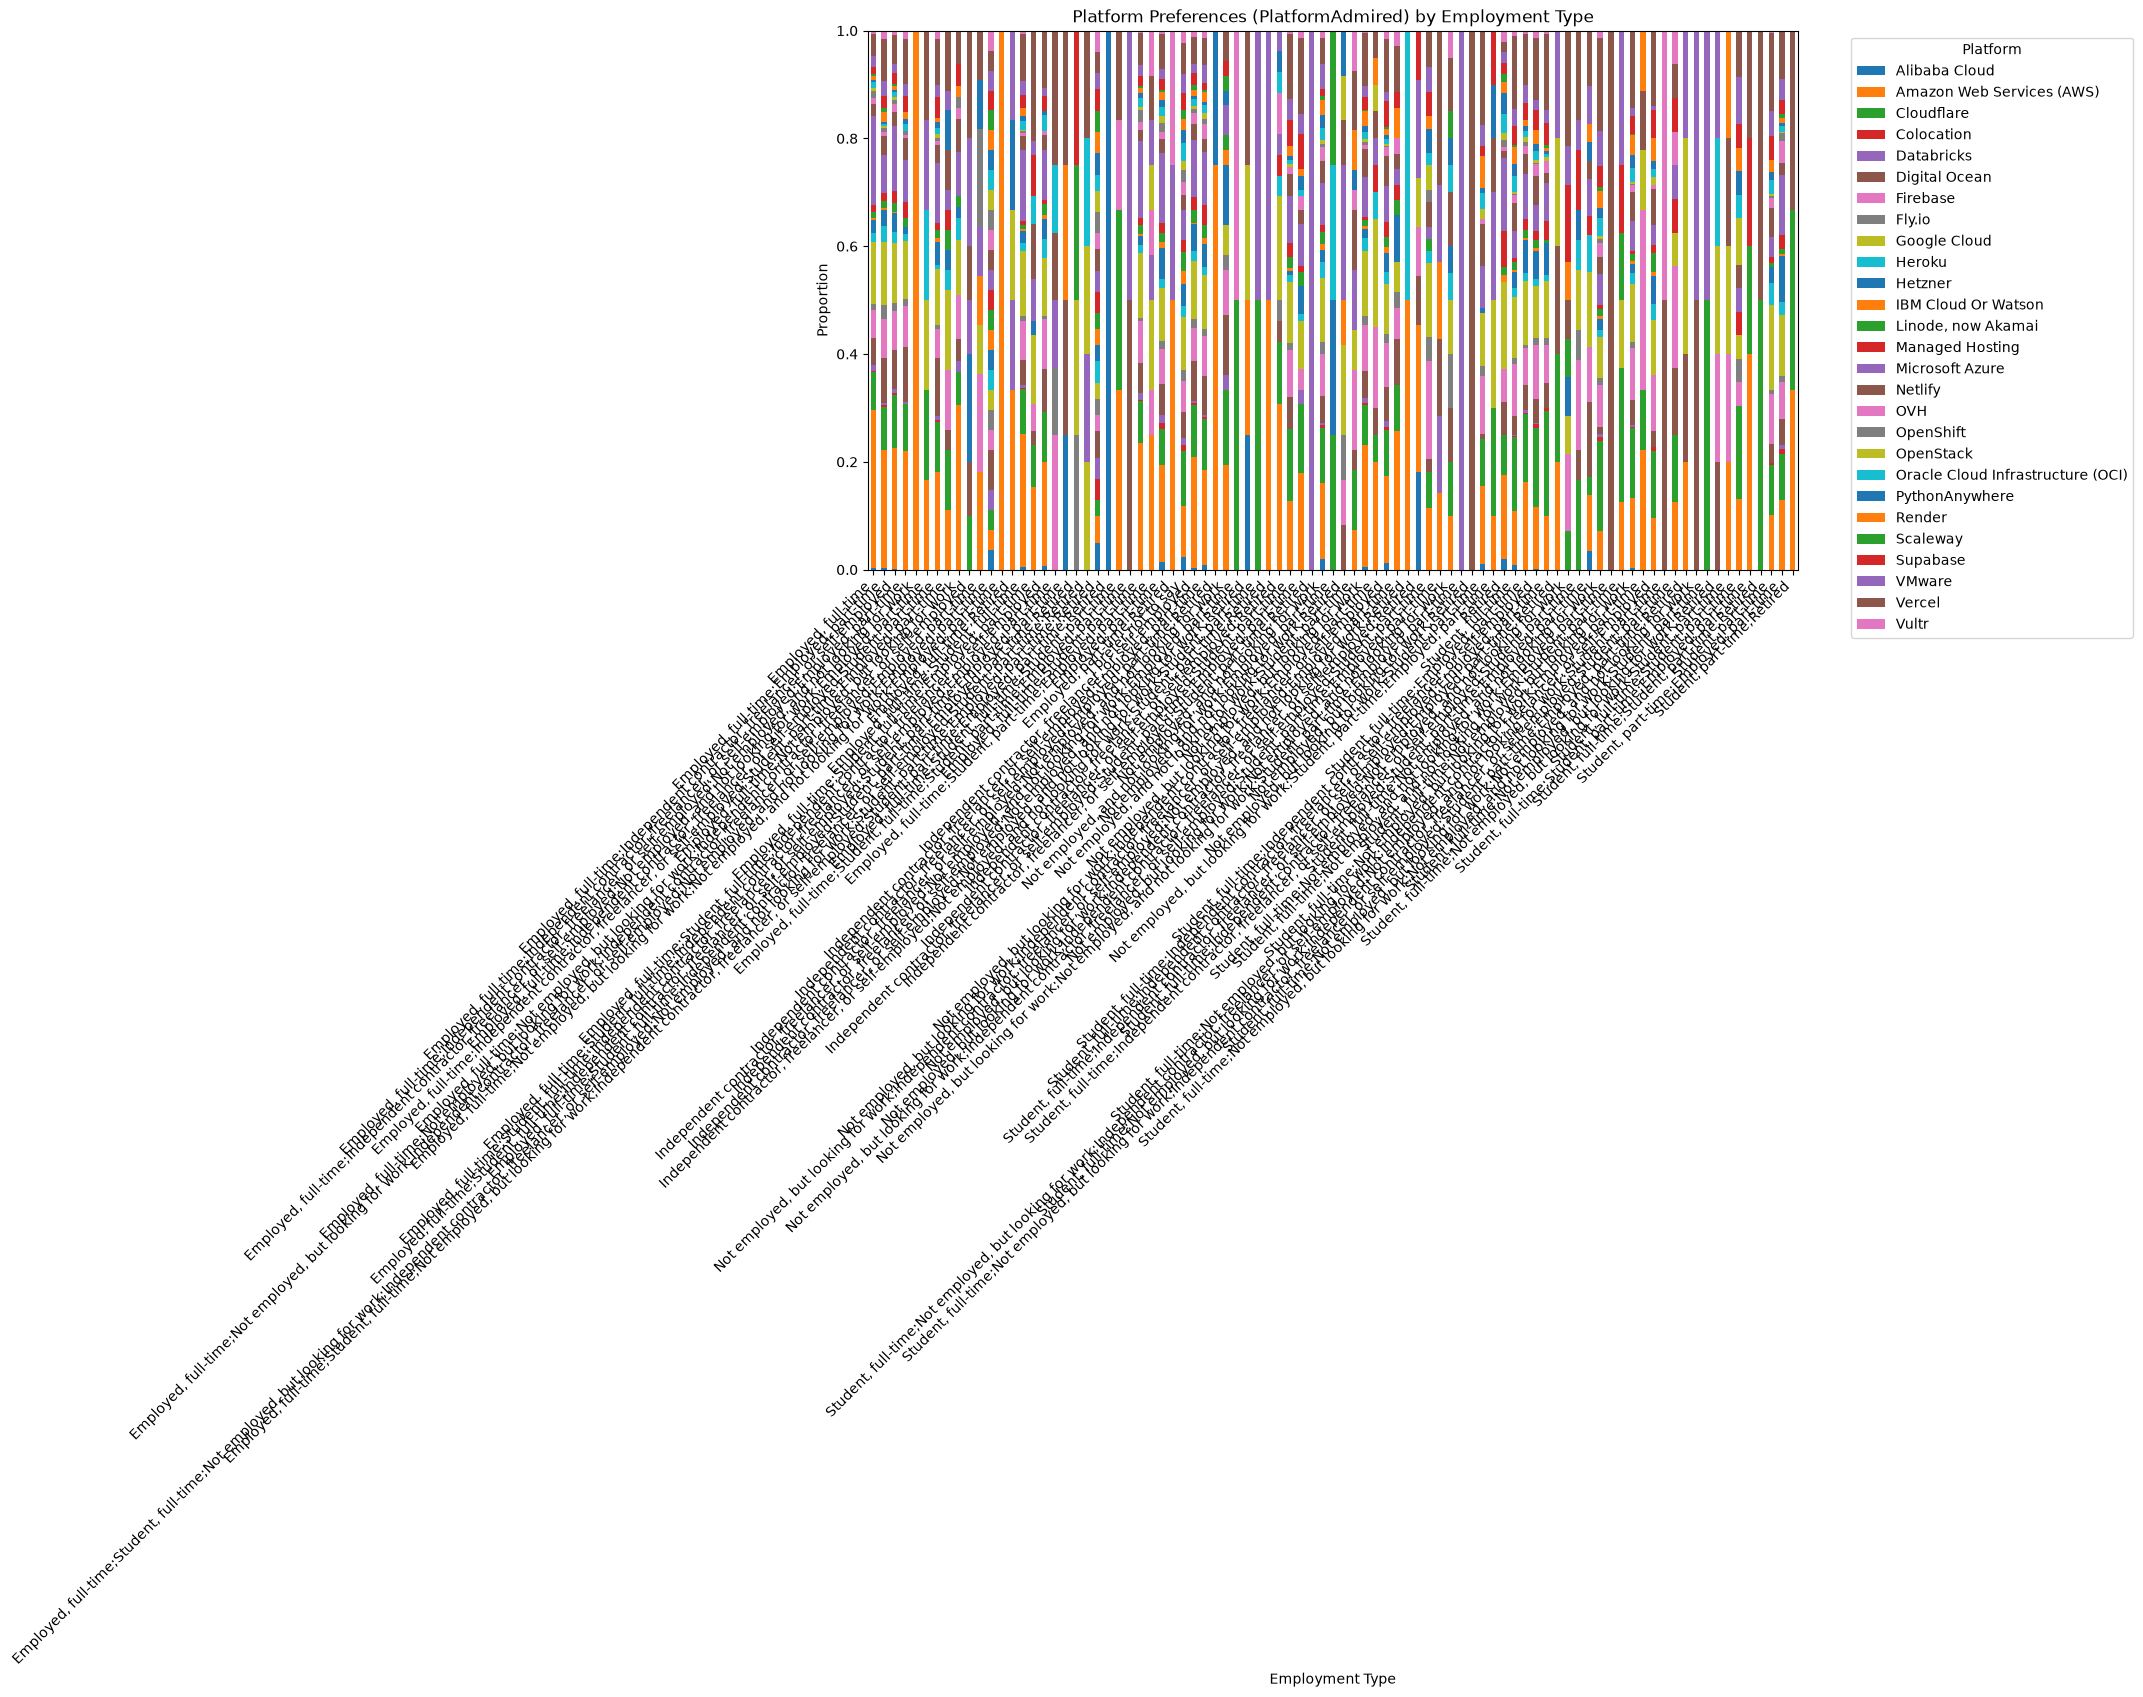

In [12]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# Handle delimited values in 'PlatformAdmired' column if multiple platforms are listed
df_platform = df.copy()
df_platform['PlatformAdmired'] = df_platform['PlatformAdmired'].str.split(';')
df_platform = df_platform.explode('PlatformAdmired')

# Count occurrences across Employment status and PlatformAdmired
platform_counts = df_platform.groupby(['Employment', 'PlatformAdmired']).size().unstack(fill_value=0)

# Normalize by row to get proportions per employment type
platform_props = platform_counts.div(platform_counts.sum(axis=1), axis=0)

# Plot stacked bar chart
platform_props.plot(kind='bar', stacked=True, figsize=(12, 7))

plt.title('Platform Preferences (PlatformAdmired) by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show() 

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
